# Introduction

The following datasets coming from Kaggle site. We pull the data using the following prodivded codes: 

import kagglehub

#### Download latest version
path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")

print("Path to dataset files:", path)

In [1]:
import pandas as pd 
import numpy as np
from functools import reduce

import xlsxwriter
import openpyxl

import matplotlib.pyplot as plt
import io

import seaborn as sns

In [2]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [3]:

# Download the latest version
file_1 = "Player Career Info.csv"
file_2 = "Player Totals.csv"
file_3 = "Player Award Shares.csv"
file_4 = "Player Per Game.csv"
file_5 = "Player Play By Play.csv"
file_6 = "Player Season Info.csv"
file_7 = "Player Shooting.csv"




player_career_info — Do not use this dataset, as it is not useful and cannot be merged with other datasets.

From below we should have merge keys as: season, player name, player ID to ensure 1-1 merge

In [4]:
player_career_info = pd.read_csv(file_1)

print("This is player_career_info columns:", player_career_info.columns)

player_total = pd.read_csv(file_2)
player_total = player_total.sort_values(by=["season", "player", "player_id"], ascending=[True,True,True])
print("This is player_total columns:", player_total.columns)

player_Award_Shares = pd.read_csv(file_3)
player_Award_Shares = player_Award_Shares.sort_values(by=["season","award", "player", "player_id"], ascending=[True,True,True,True])
print("This is player_Award_Shares columns:", player_Award_Shares.columns)

player_per_game = pd.read_csv(file_4)
player_per_game = player_per_game.sort_values(by=["season", "player", "player_id"], ascending=[True,True,True])
print("This is player_per_game columns:", player_per_game.columns)

player_play_by_play = pd.read_csv(file_5)
player_play_by_play = player_play_by_play.sort_values(by=["season", "player", "player_id"], ascending=[True,True,True])
print("This is player_play_by_play columns:", player_play_by_play.columns)

player_season_info = pd.read_csv(file_6)
player_season_info = player_season_info.sort_values(by=["season", "player", "player_id"], ascending=[True,True,True])
print("This is player_season_info columns:", player_season_info.columns)

player_shooting = pd.read_csv(file_7)
player_shooting = player_shooting.sort_values(by=["season", "player", "player_id"], ascending=[True,True,True])
print("This is player_shooting columns:", player_shooting.columns)


This is player_career_info columns: Index(['player', 'player_id', 'pos', 'ht_in_in', 'wt', 'birth_date',
       'colleges', 'from', 'to', 'debut', 'hof'],
      dtype='object')
This is player_total columns: Index(['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs',
       'mp', 'fg', 'fga', 'fg_percent', 'x3p', 'x3pa', 'x3p_percent', 'x2p',
       'x2pa', 'x2p_percent', 'e_fg_percent', 'ft', 'fta', 'ft_percent', 'orb',
       'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'trp_dbl'],
      dtype='object')
This is player_Award_Shares columns: Index(['season', 'award', 'player', 'player_id', 'age', 'first', 'pts_won',
       'pts_max', 'share', 'winner'],
      dtype='object')
This is player_per_game columns: Index(['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs',
       'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent',
       'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game',
       'x2pa_per_game', 'x2p_percent',

In [5]:
player_total.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp,fg,fga,fg_percent,x3p,x3pa,x3p_percent,x2p,x2pa,x2p_percent,e_fg_percent,ft,fta,ft_percent,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl
32414,1947,BAA,Al Brightman,brighal01,23.0,BOS,NaN,58,NaN,NaN,223,870,0.256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121,193,0.627,NaN,NaN,NaN,60,NaN,NaN,NaN,115.0,567,0.0
32502,1947,BAA,Al Lujack,lujacal01,26.0,WSC,NaN,5,NaN,NaN,1,8,0.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,5,0.400,NaN,NaN,NaN,0,NaN,NaN,NaN,6.0,4,0.0
32537,1947,BAA,Al Negratti,negraal01,25.0,WSC,NaN,11,NaN,NaN,13,69,0.188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,8,0.625,NaN,NaN,NaN,5,NaN,NaN,NaN,20.0,31,0.0
32536,1947,BAA,Angelo Musi,musian01,28.0,PHW,NaN,60,NaN,NaN,230,818,0.281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102,123,0.829,NaN,NaN,NaN,26,NaN,NaN,NaN,120.0,562,0.0
32508,1947,BAA,Ariel Maughan,maughar01,23.0,DTF,NaN,59,NaN,NaN,224,929,0.241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84,114,0.737,NaN,NaN,NaN,57,NaN,NaN,NaN,180.0,532,0.0


In [6]:
df = [player_total, player_Award_Shares, player_per_game, player_play_by_play, player_season_info, player_shooting]



In [7]:

def common_columns(datasets):
    """
    Find column names that exist in all datasets. This helps with merging df
    
    Parameters:
        datasets (list): List of pandas DataFrames.
    
    Returns:
        set: Columns common to all datasets.
    """
    if not datasets:
        return set()
    
    col_sets = [set(df.columns) for df in datasets]
    return set.intersection(*col_sets)


In [8]:
common_columns(df)

{'age', 'player', 'player_id', 'season'}

In [9]:
# rows and columns before drop duplicates
print("This is player_career_info shape:", player_career_info.shape)

print("This is player_total columns:", player_total.shape)

print("This is player_Award_Shares columns:", player_Award_Shares.shape)

print("This is player_per_game columns:", player_per_game.shape)

print("This is player_play_by_play columns:", player_play_by_play.shape)

print("This is player_season_info columns:", player_season_info.shape)

print("This is player_shooting columns:", player_shooting.shape)


This is player_career_info shape: (5313, 11)
This is player_total columns: (32606, 33)
This is player_Award_Shares columns: (3398, 10)
This is player_per_game columns: (32606, 32)
This is player_play_by_play columns: (17521, 26)
This is player_season_info columns: (32606, 8)
This is player_shooting columns: (17521, 32)


In [10]:
#check duplicate
player_total = player_total.drop_duplicates(subset=["season","lg", "player", "player_id", "team"])
print("this is player_total after: ", player_total.shape)

player_per_game = player_per_game.drop_duplicates(subset=["season","lg", "player", "player_id", "team"])
print("this is player_per_game after: ", player_per_game.shape)

player_season_info = player_season_info.drop_duplicates(subset=["season","lg", "player", "player_id", "team"])
print("this is player_season_info after: ", player_season_info.shape)

player_Award_Shares = player_Award_Shares.drop_duplicates(subset=["season","award", "player", "player_id"])
print("this is player_Award_Shares after: ", player_Award_Shares.shape)

player_play_by_play = player_play_by_play.drop_duplicates(subset=["season","lg", "player", "player_id", "team"])
print("this is player_play_by_play after: ", player_play_by_play.shape)

player_shooting = player_shooting.drop_duplicates(subset=["season","lg", "player", "player_id", "team"])
print("this is player_shooting after: ", player_shooting.shape)





this is player_total after:  (32606, 33)
this is player_per_game after:  (32606, 32)
this is player_season_info after:  (32606, 8)
this is player_Award_Shares after:  (3398, 10)
this is player_play_by_play after:  (17521, 26)
this is player_shooting after:  (17521, 32)


In [11]:
#filter for 1980 or higher
player_total = player_total[player_total["season"] >= 1980]
print("this is player_total filter for 1980+: ", player_total.shape)

player_per_game = player_per_game[player_per_game["season"] >= 1980]
print("this is player_per_game filter for 1980+: ", player_per_game.shape)

player_season_info = player_season_info[player_season_info["season"] >= 1980]
print("this is player_season_info filter for 1980+: ", player_season_info.shape)

player_Award_Shares = player_Award_Shares[player_Award_Shares["season"] >= 1980]
print("this is player_Award_Shares filter for 1980+: ", player_Award_Shares.shape)

player_play_by_play = player_play_by_play[player_play_by_play["season"] >= 1980]
print("this is player_play_by_play filter for 1980+: ", player_play_by_play.shape)

player_shooting = player_shooting[player_shooting["season"] >= 1980]
print("this is player_shooting filter for 1980+: ", player_shooting.shape)



this is player_total filter for 1980+:  (24616, 33)
this is player_per_game filter for 1980+:  (24616, 32)
this is player_season_info filter for 1980+:  (24616, 8)
this is player_Award_Shares filter for 1980+:  (2897, 10)
this is player_play_by_play filter for 1980+:  (17521, 26)
this is player_shooting filter for 1980+:  (17521, 32)


## EDA -

Data exploration

In [12]:
player_total.describe()

,season,age,g,gs,mp,fg,fga,fg_percent,x3p,x3pa,x3p_percent,x2p,x2pa,x2p_percent,e_fg_percent,ft,fta,ft_percent,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl
count,24616.000000,24616.000000,24616.000000,24023.000000,24616.000000,24616.000000,24616.000000,24484.000000,24616.000000,24616.000000,20736.000000,24616.000000,24616.000000,24395.000000,24484.000000,24616.000000,24616.000000,23473.000000,24616.000000,24616.000000,24616.000000,24616.000000,24616.000000,24616.000000,24616.000000,24616.000000,24616.000000,24615.000000
mean,2005.195036,26.652624,47.488585,22.453857,1102.884669,177.702592,384.627478,0.439860,27.671352,78.379266,0.265716,150.031240,306.248213,0.469449,0.474783,86.797327,114.689592,0.727354,55.148724,139.802486,194.951211,106.625650,36.451292,22.763487,67.370775,100.391696,469.873863,0.110949
std,13.027589,4.051199,26.620270,27.884026,898.533376,177.148092,370.559923,0.102106,44.236245,117.370485,0.169775,160.396005,318.562255,0.111139,0.106344,103.415747,131.745498,0.148071,62.835935,139.532690,196.291692,132.936274,36.024217,34.113225,64.604199,78.221420,471.951063,0.949869
min,1980.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1995.000000,24.000000,23.000000,0.000000,282.000000,33.000000,79.000000,0.400000,0.000000,2.000000,0.167000,25.000000,56.000000,0.429000,0.439000,13.000000,19.000000,0.667000,10.000000,30.000000,43.000000,16.000000,8.000000,3.000000,15.000000,30.000000,88.000000,0.000000
50%,2006.000000,26.000000,51.000000,7.000000,915.000000,121.000000,271.000000,0.444000,5.000000,19.000000,0.311000,95.000000,198.000000,0.475000,0.484000,49.000000,68.000000,0.750000,32.000000,100.000000,137.000000,59.000000,26.000000,11.000000,49.000000,89.000000,320.000000,0.000000
75%,2017.000000,29.000000,73.000000,42.000000,1798.000000,273.000000,593.000000,0.488250,39.000000,113.000000,0.370000,224.000000,457.000000,0.518000,0.524000,123.000000,164.000000,0.819000,77.000000,204.000000,281.000000,145.000000,54.000000,28.000000,102.000000,157.000000,721.000000,0.000000
max,2025.000000,44.000000,85.000000,83.000000,3533.000000,1098.000000,2279.000000,1.000000,402.000000,1028.000000,1.000000,1086.000000,2213.000000,1.000000,1.500000,833.000000,972.000000,1.000000,573.000000,1007.000000,1530.000000,1164.000000,301.000000,456.000000,464.000000,386.000000,3041.000000,42.000000


In [13]:
def describe_to_excel(datasets, filename="descriptions.xlsx", names=None):
    """
    Run .describe() on multiple datasets and save results into one Excel file,
    separated by two blank rows with labels.

    Parameters
    ----------
    datasets : list of pd.DataFrame
        List of DataFrames to summarize.
    filename : str, default "descriptions.xlsx"
        Output Excel filename.
    names : list of str, optional
        Names to label each dataset. Must match the length of datasets.
        If None, defaults to "Dataset 1", "Dataset 2", etc.
    """
    if names is None:
        names = [f"Dataset {i}" for i in range(1, len(datasets) + 1)]
    elif len(names) != len(datasets):
        raise ValueError("Length of names list must match number of datasets")

    with pd.ExcelWriter(filename, engine="xlsxwriter") as writer:
        row = 0
        for name, df in zip(names, datasets):
            # Label row
            label_text = pd.DataFrame([[name]])
            label_text.to_excel(writer, sheet_name="Summary", startrow=row, index=False, header=False)
            row += 1

            # Describe block
            desc = df.describe(include="all").transpose()
            desc.to_excel(writer, sheet_name="Summary", startrow=row, index=True)

            # Move row pointer down (block height + 2 blank rows)
            row += len(desc) + 3

    print(f"Saved descriptions for {len(datasets)} datasets to '{filename}'")

    

def scatter_all_vars_grouped(df, x="player"):
    """
    Create scatter plots of all numeric columns grouped by 'player'.
    Each player gets a single point (aggregated, mean by default).

    Parameters
    ----------
    df : pd.DataFrame
        Dataset to plot.
    x : str, default "player"
        Column to use for x-axis.
    """
    # Group by player and take mean of numeric values
    grouped = df.groupby(x).mean(numeric_only=True).reset_index()
    numeric_cols = grouped.select_dtypes(include="number").columns

    for col in numeric_cols:
        plt.figure(figsize=(10, 5))
        plt.scatter(grouped[x], grouped[col], alpha=0.7)
        plt.title(f"{col} by {x} (grouped)")
        plt.xlabel(x)
        plt.ylabel(col)
        plt.xticks(rotation=90)  # vertical labels if many names
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()
        
def scatter_all_vars_timeline(df, time_col="season", group_col="player"):
    """
    Create scatter plots for all numeric columns across a timeline (e.g., season).
    Groups by season and player, then averages values if multiple rows.
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing a time column and player column.
    time_col : str, default "season"
        Column to use as timeline (x-axis).
    group_col : str, default "player"
        Column to group by (legend).
    """
    # Group by season + player
    grouped = df.groupby([time_col, group_col]).mean(numeric_only=True).reset_index()
    numeric_cols = grouped.select_dtypes(include="number").columns.drop(time_col, errors="ignore")

    for col in numeric_cols:
        plt.figure(figsize=(10, 6))
        for player, data in grouped.groupby(group_col):
            plt.scatter(data[time_col], data[col], label=player, alpha=0.7)
            plt.plot(data[time_col], data[col], alpha=0.5)  # connect points
            
        plt.title(f"{col} over {time_col}")
        plt.xlabel(time_col)
        plt.ylabel(col)
#        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()
        
def missing_summary(df):
    """
    Return a summary of missing values per column.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset to check.

    Returns
    -------
    pd.DataFrame
        Table with columns: variable, missing_count, missing_percent
    """
    total_rows = len(df)
    summary = (
        df.isna()
          .sum()
          .reset_index()
          .rename(columns={"index": "variable", 0: "missing_count"})
    )
    summary["missing_percent"] = (summary["missing_count"] / total_rows * 100).round(2)
    return summary.sort_values(by="missing_count", ascending=False).reset_index(drop=True)

def hist_all_vars(df, bins=20):
    """
    Plot histograms for all numeric variables in a dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset to plot.
    bins : int, default 20
        Number of histogram bins.
    """
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        plt.hist(df[col].dropna(), bins=bins, alpha=0.7, color="skyblue", edgecolor="black")
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.show()

#### Histograms

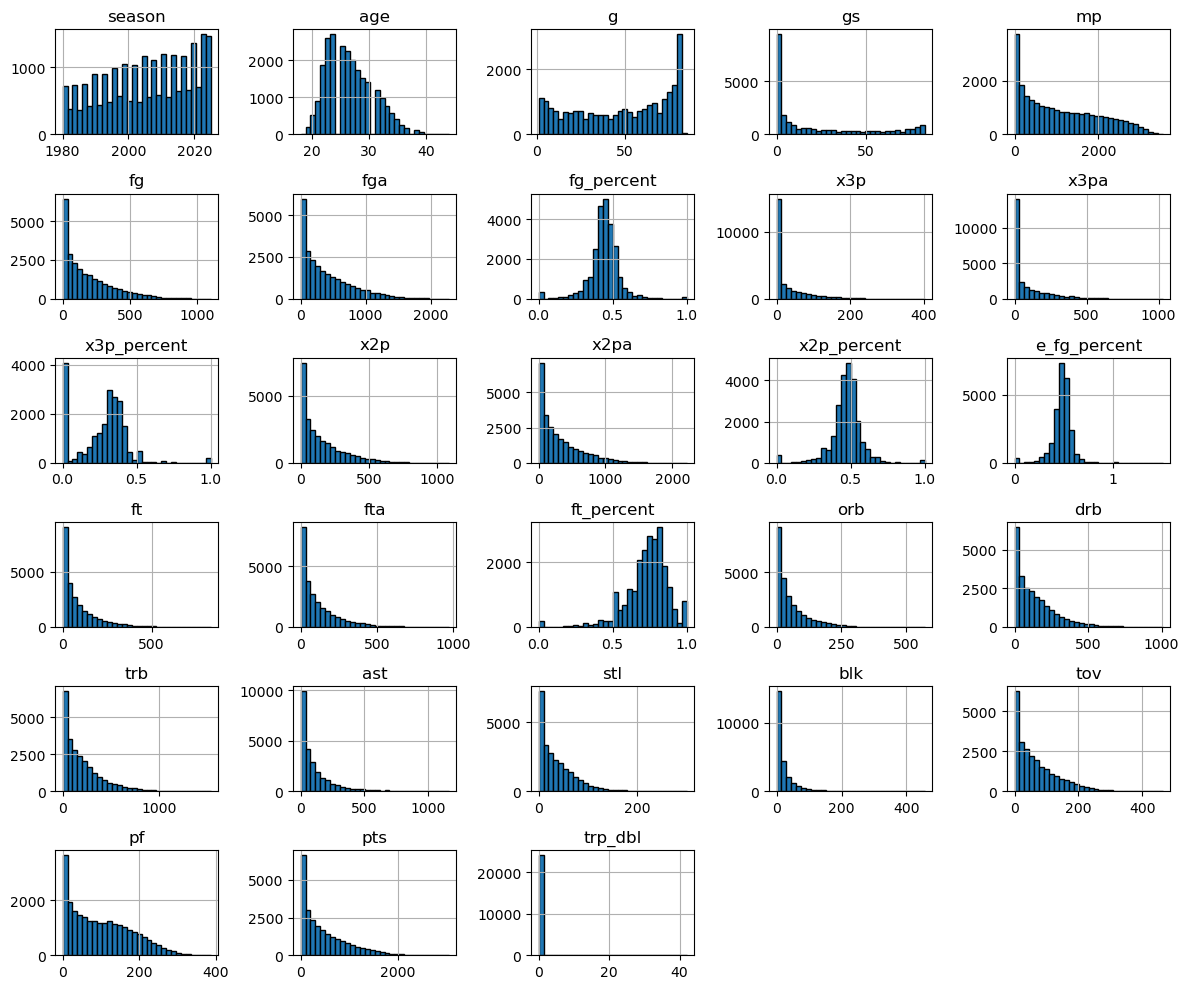

In [14]:
# player_total - Plot histogram for all numeric columns
player_total.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
# Save to PDF
plt.savefig("player_total_histograms.pdf")
plt.show()

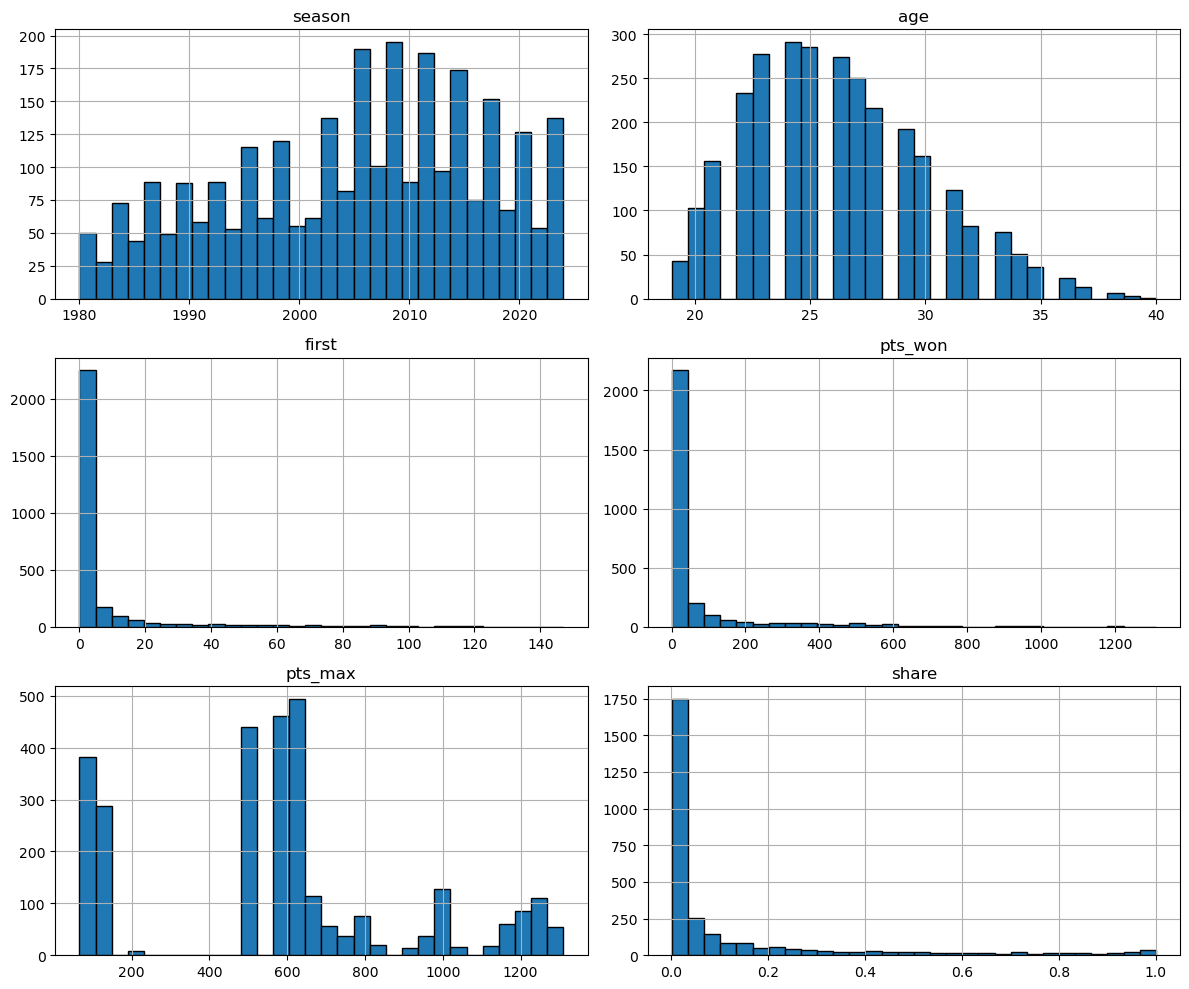

In [15]:
# player_Award_Shares - Plot histogram for all numeric columns
player_Award_Shares.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
# Save to PDF
plt.savefig("player_Award_Shares_histograms.pdf")
plt.show()

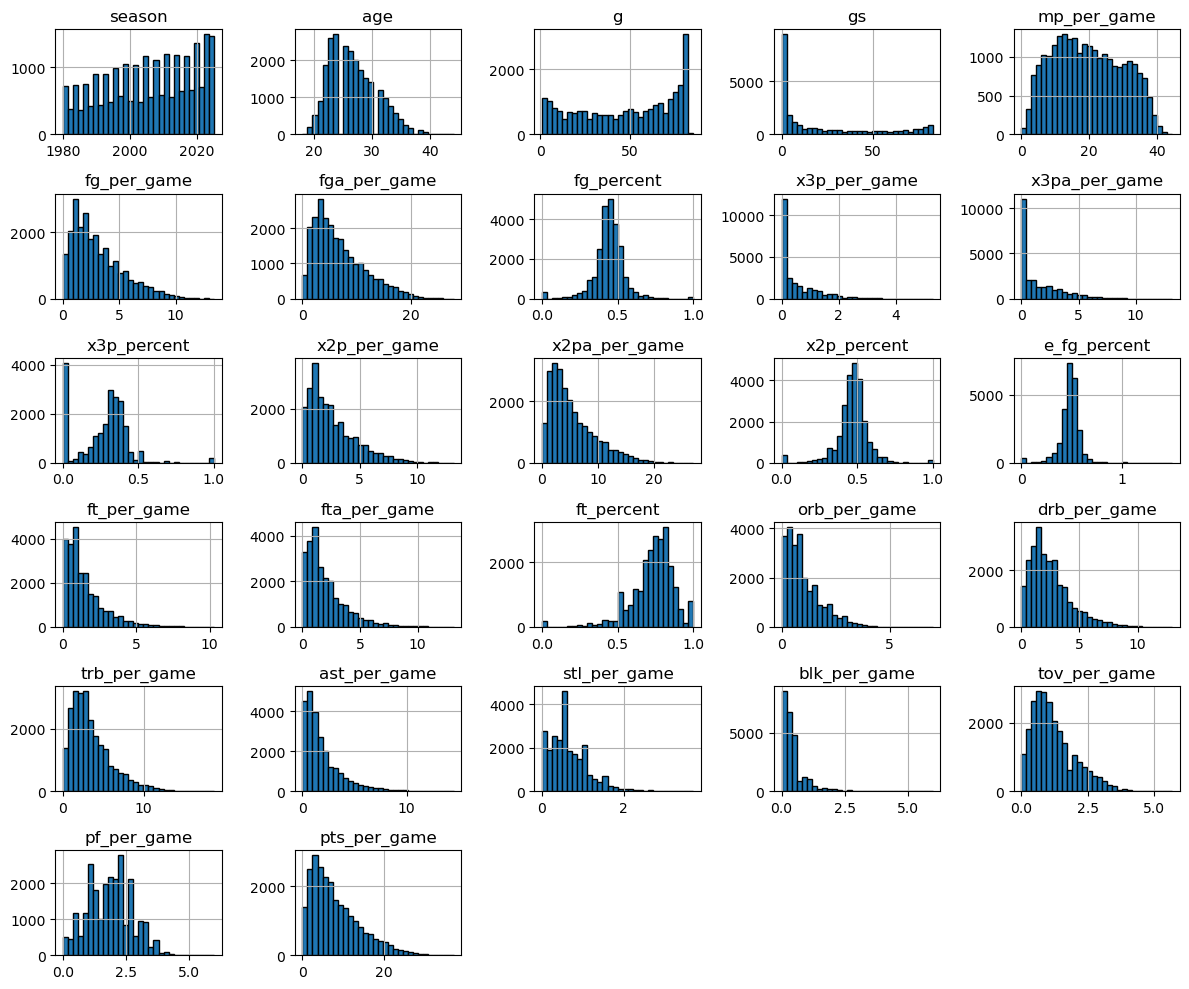

In [16]:
# player_per_game - Plot histogram for all numeric columns
player_per_game.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
# Save to PDF
plt.savefig("player_per_game_histograms.pdf")
plt.show()

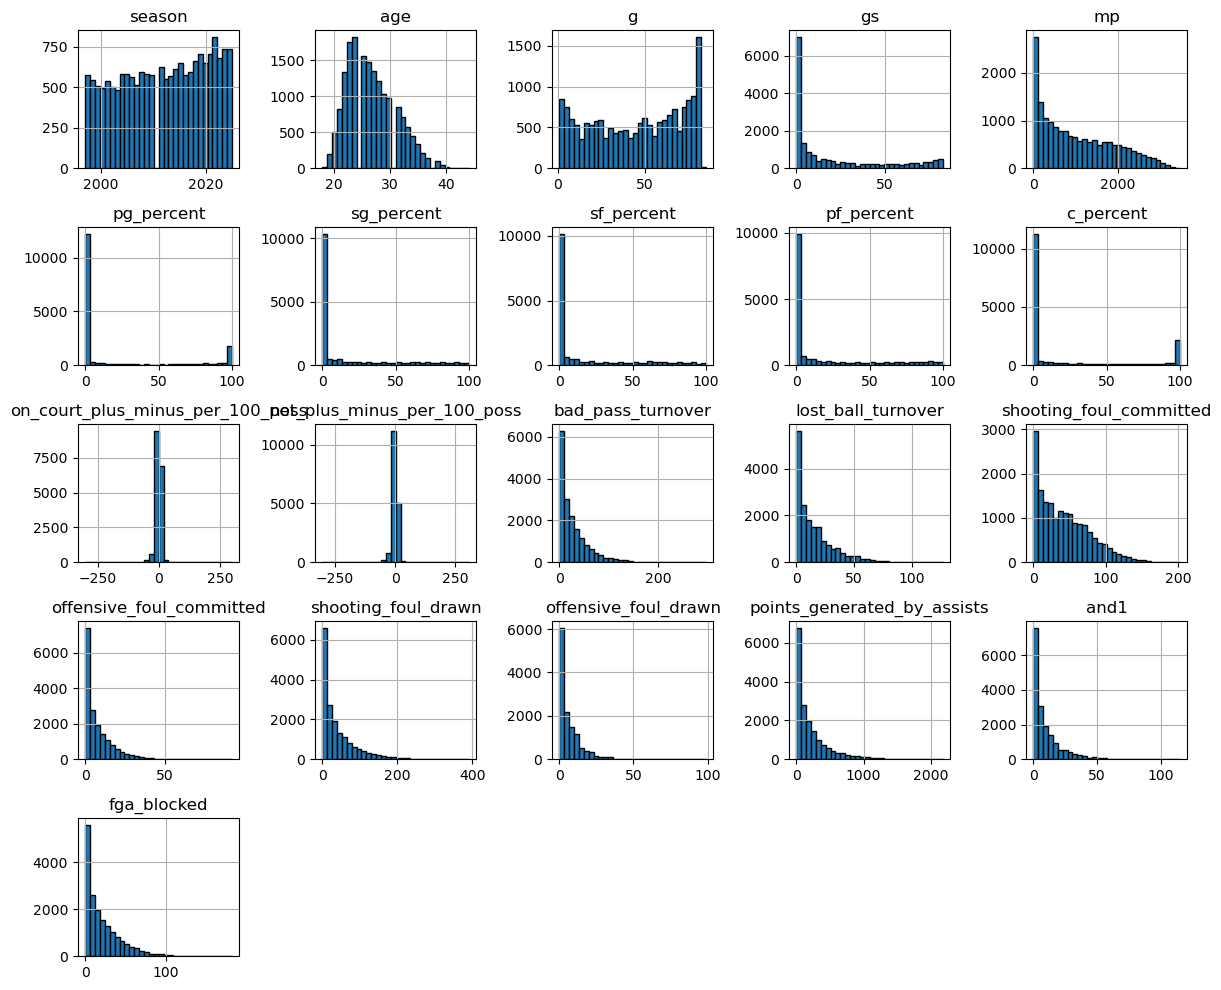

In [17]:
# player_play_by_play - Plot histogram for all numeric columns
player_play_by_play.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
# Save to PDF
plt.savefig("player_play_by_play_histograms.pdf")
plt.show()

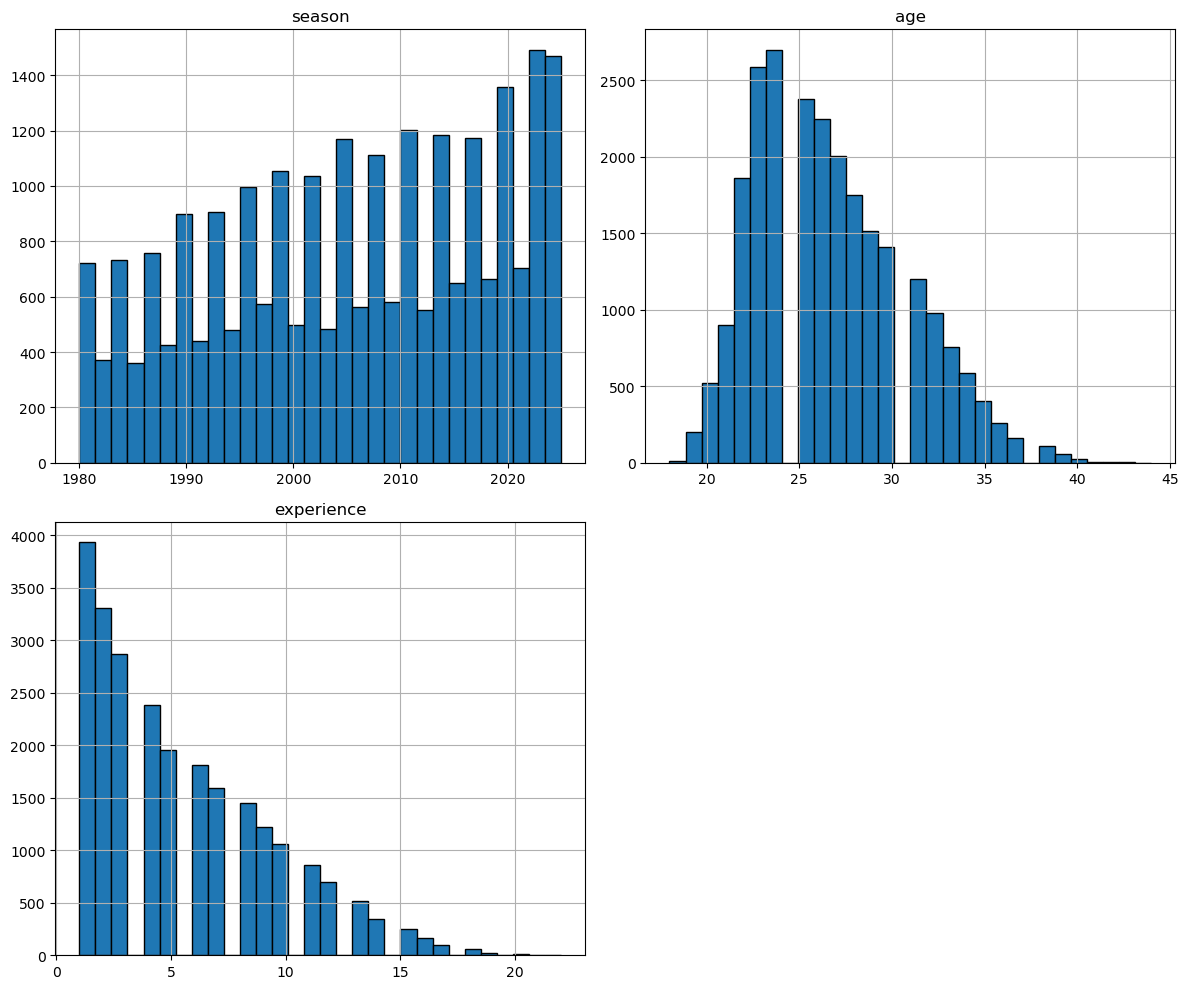

In [18]:
# player_season_info - Plot histogram for all numeric columns
player_season_info.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
# Save to PDF
plt.savefig("player_season_info_histograms.pdf")
plt.show()

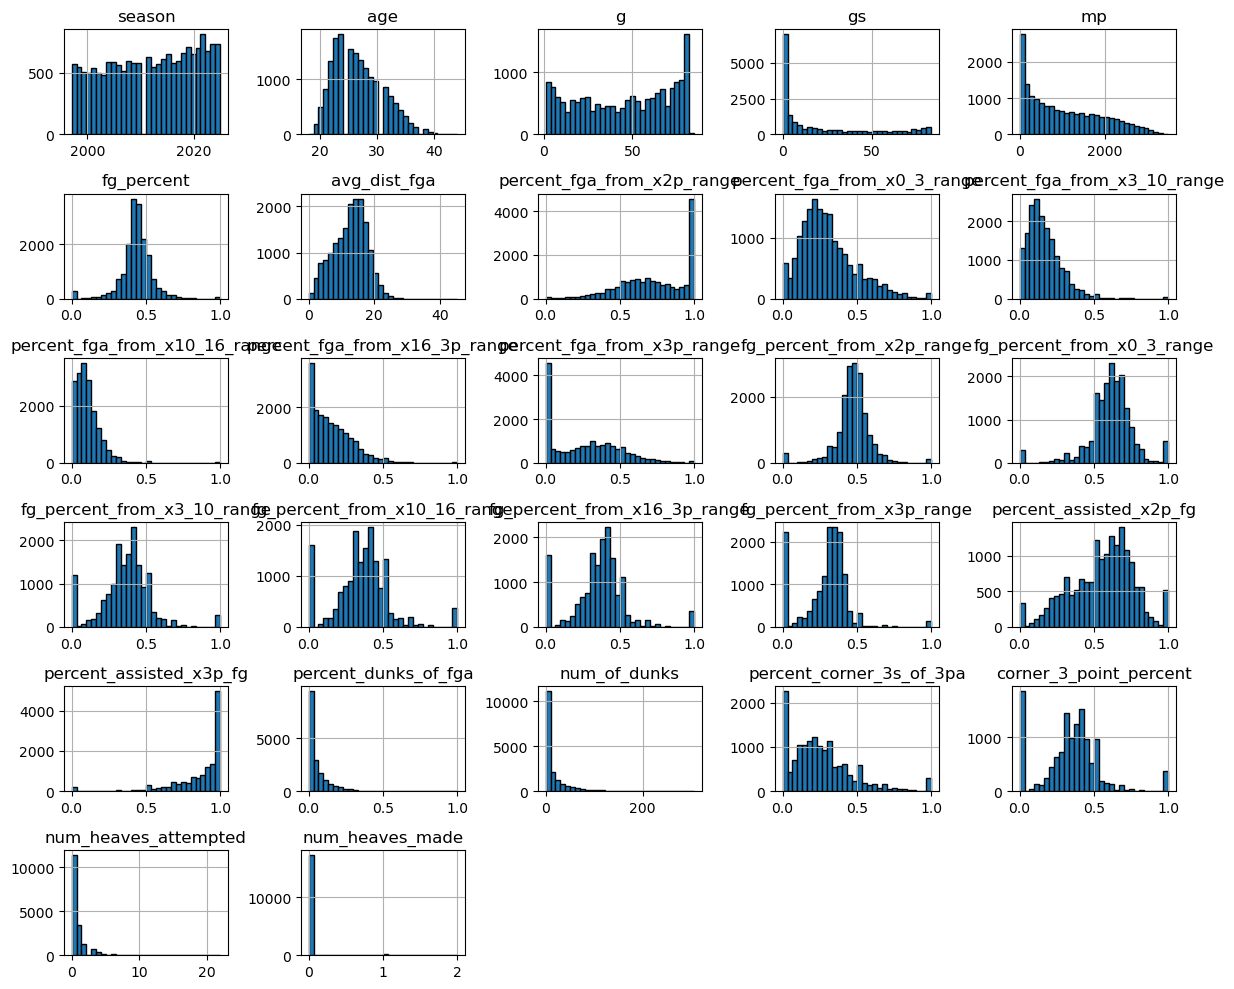

In [19]:
# player_shooting - Plot histogram for all numeric columns
player_shooting.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
# Save to PDF
plt.savefig("player_shooting_histograms.pdf")
plt.show()

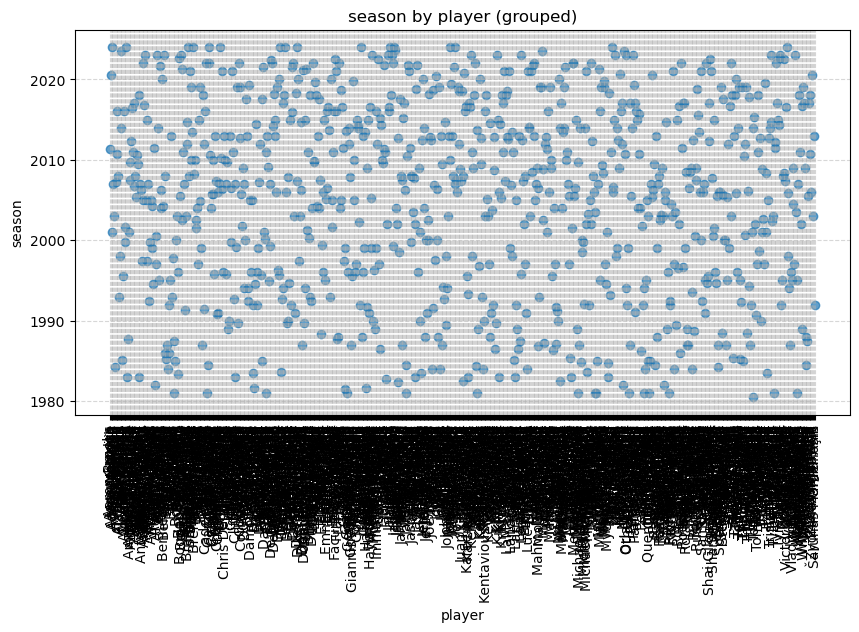

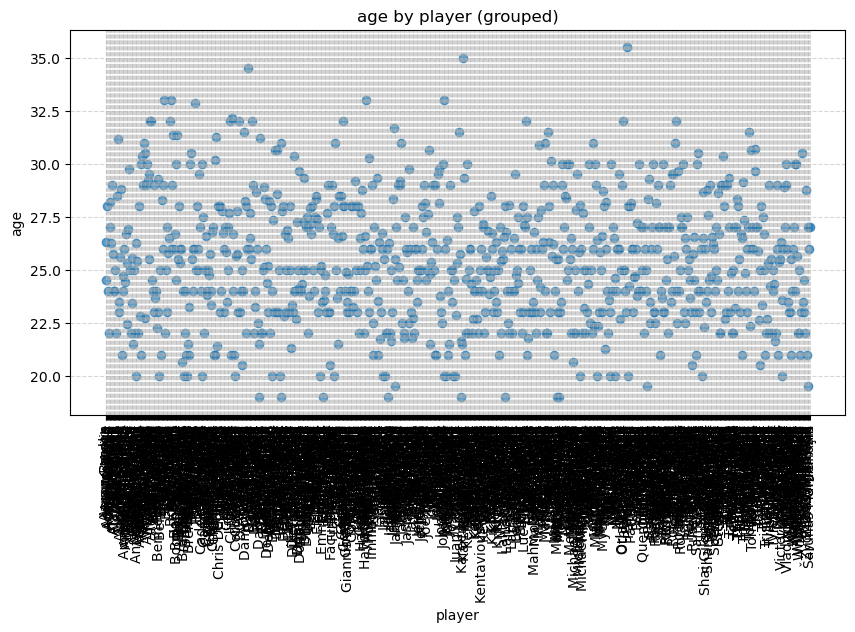

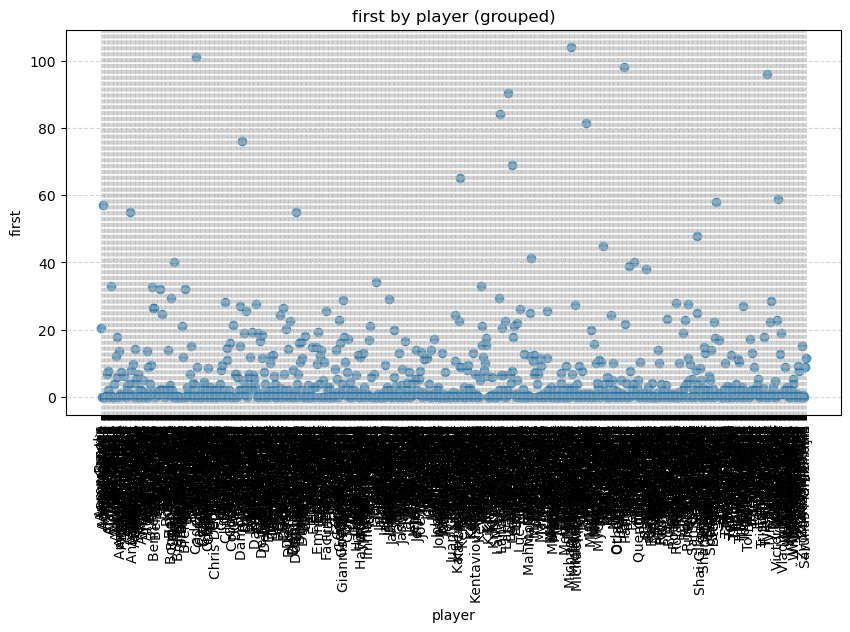

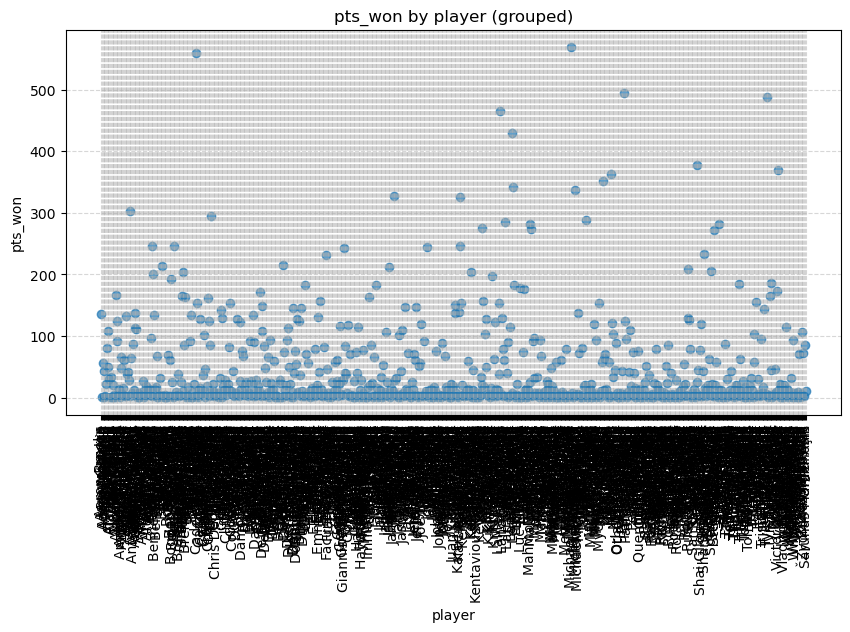

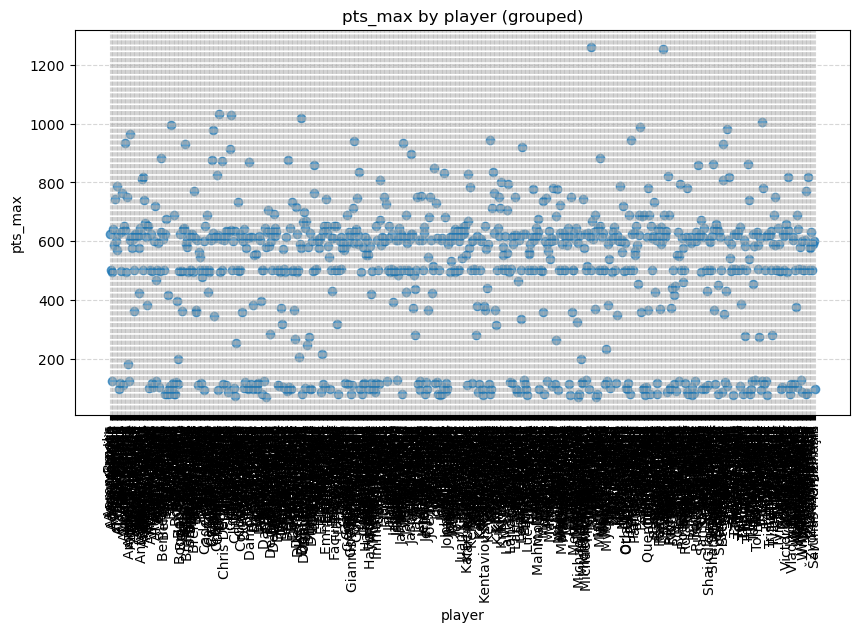

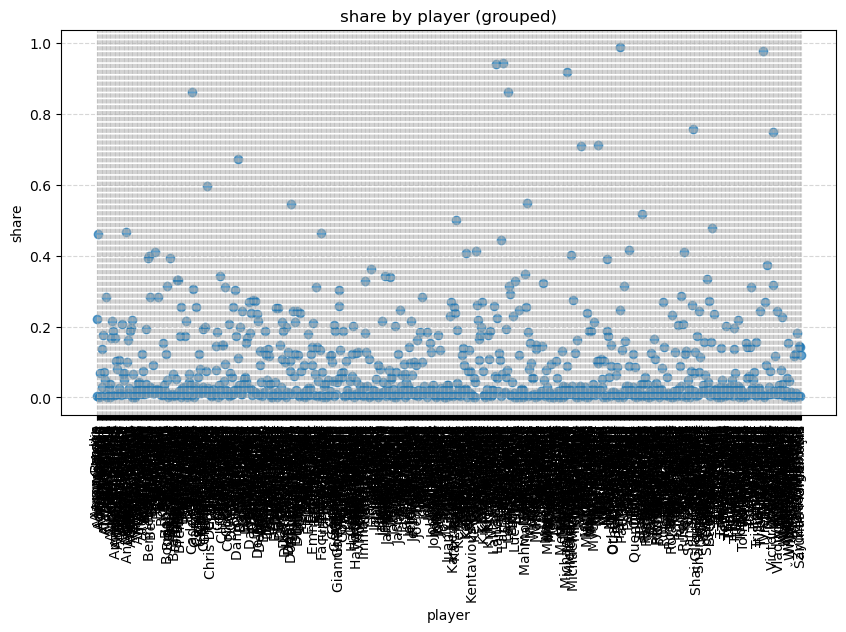

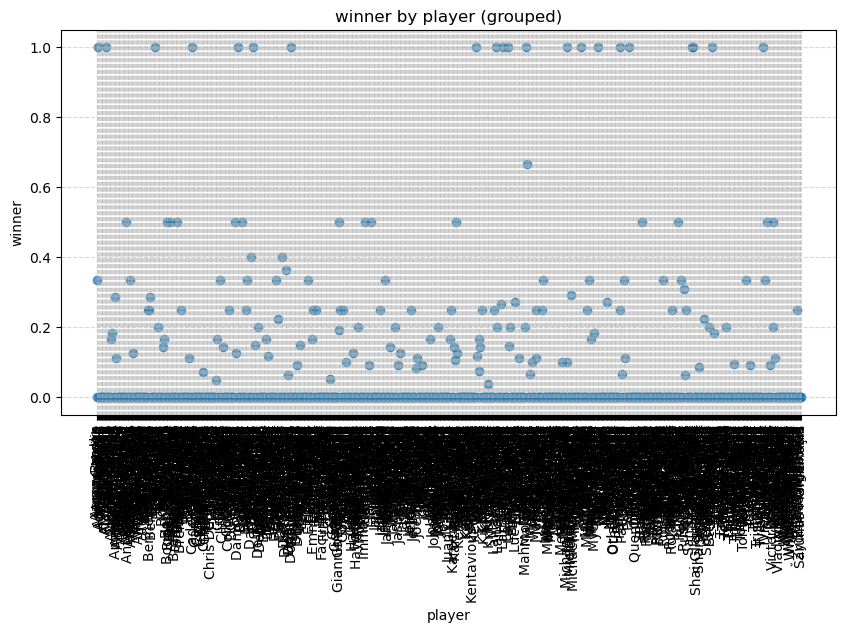

In [20]:
scatter_all_vars_grouped(player_Award_Shares, x="player")

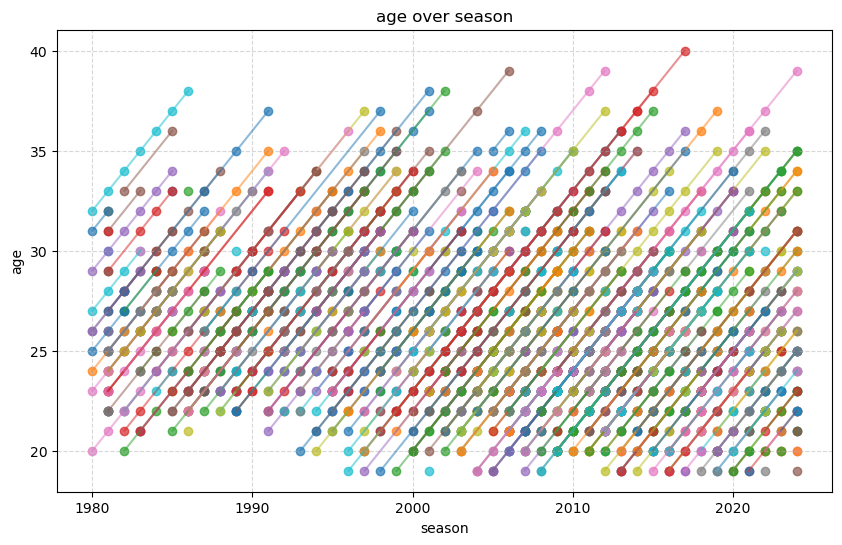

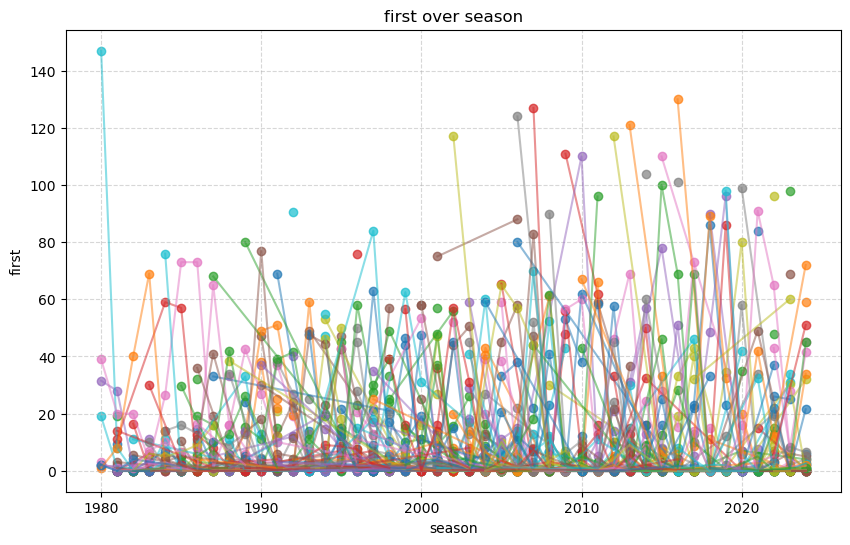

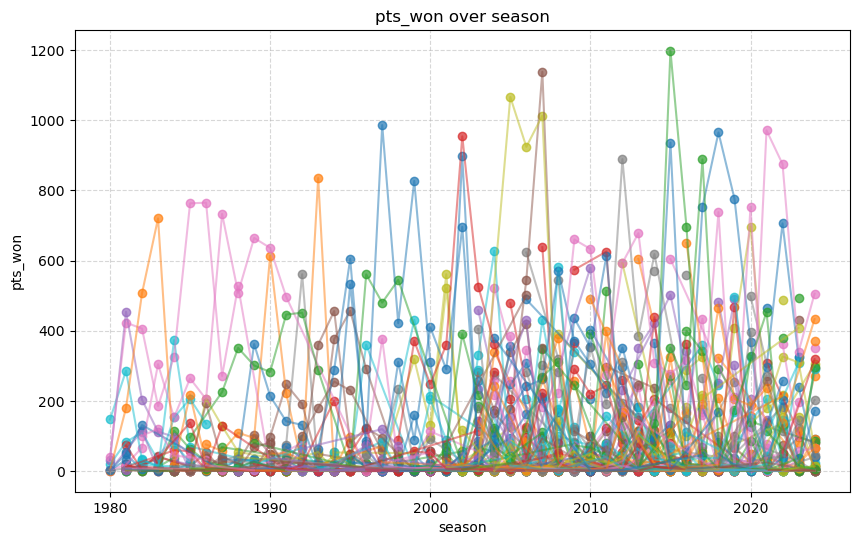

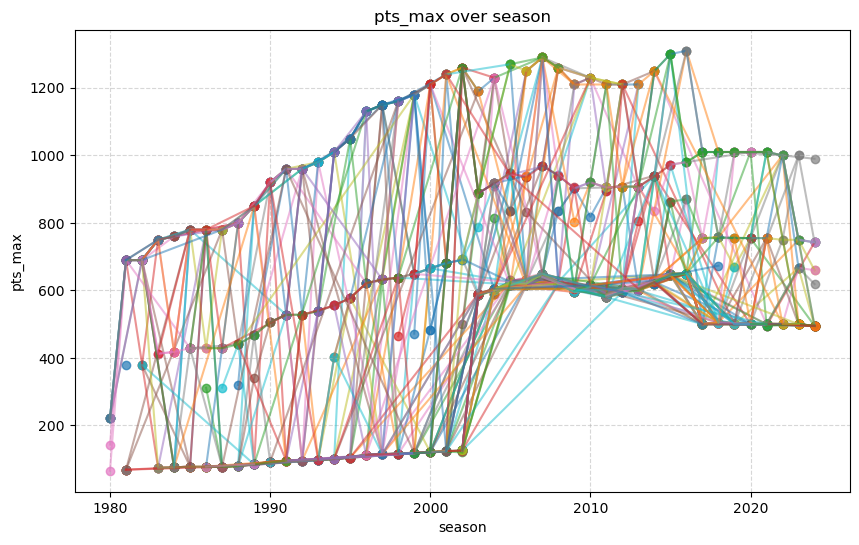

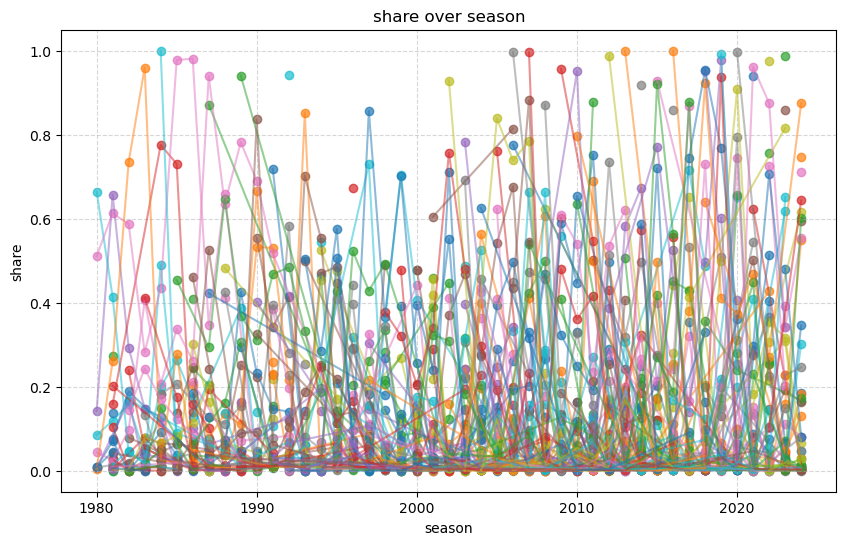

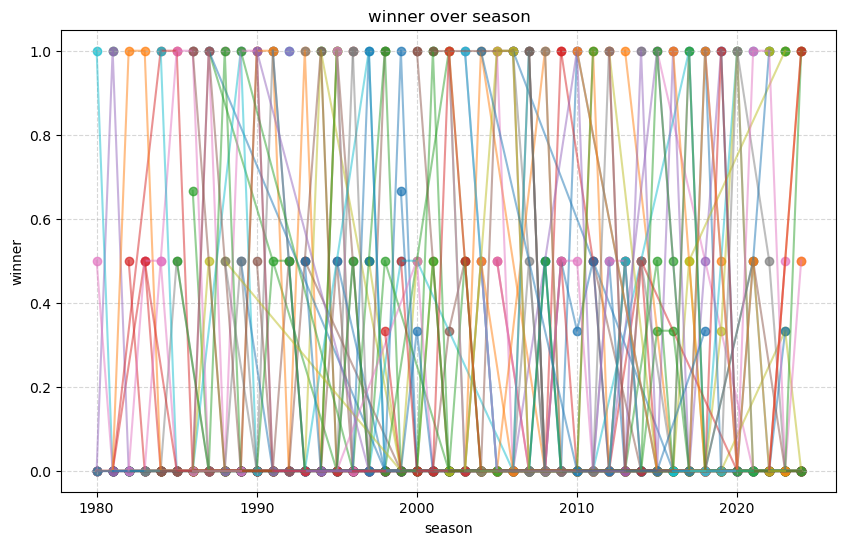

In [21]:
scatter_all_vars_timeline(player_Award_Shares, time_col="season", group_col="player")

In [22]:
#missing_summary(player_Award_Shares)

#### Missing values

In [23]:
def check_missing_values(df):
    """
    Check missing values for all variables in a dataset.
    
    Parameters:
        df (pd.DataFrame): The dataset
    
    Returns:
        pd.DataFrame: Summary of missing values (count and percentage)
    """
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    result = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percent": missing_percent.round(2)
    })
    
    # Keep only variables with at least one missing value
    result = result[result["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
    
    return result



In [24]:
check_missing_values(player_total)

,Missing Count,Missing Percent
x3p_percent,3880,15.76
ft_percent,1143,4.64
gs,593,2.41
x2p_percent,221,0.90
fg_percent,132,0.54
e_fg_percent,132,0.54
trp_dbl,1,0.00


In [25]:
check_missing_values(player_Award_Shares)

,Missing Count,Missing Percent
player_id,1,0.03
first,1,0.03
pts_won,1,0.03
pts_max,1,0.03
share,1,0.03


In [26]:
check_missing_values(player_per_game)

,Missing Count,Missing Percent
x3p_percent,3880,15.76
ft_percent,1143,4.64
gs,593,2.41
x2p_percent,221,0.90
fg_percent,132,0.54
e_fg_percent,132,0.54


In [27]:
check_missing_values(player_play_by_play)

,Missing Count,Missing Percent
offensive_foul_drawn,4814,27.48
on_court_plus_minus_per_100_poss,9,0.05
net_plus_minus_per_100_poss,9,0.05
pg_percent,5,0.03
sg_percent,5,0.03
sf_percent,5,0.03
pf_percent,5,0.03
c_percent,5,0.03


In [28]:
check_missing_values(player_season_info)

,Missing Count,Missing Percent


In [29]:
check_missing_values(player_shooting)

,Missing Count,Missing Percent
percent_assisted_x3p_fg,4676,26.69
corner_3_point_percent,4592,26.21
percent_corner_3s_of_3pa,2458,14.03
fg_percent_from_x3p_range,2458,14.03
fg_percent_from_x16_3p_range,1626,9.28
fg_percent_from_x10_16_range,1413,8.06
fg_percent_from_x3_10_range,931,5.31
fg_percent_from_x0_3_range,593,3.38
percent_assisted_x2p_fg,494,2.82
fg_percent_from_x2p_range,190,1.08


#### Five numbers summary

In [30]:
describe_to_excel(
    [player_total, player_Award_Shares, player_per_game, player_play_by_play, player_season_info, player_shooting],
    filename="nba_described01.xlsx",
    names=["player_total", "player_Award_Shares", "player_per_game", "player_play_by_play", "player_season_info", "player_shooting"]
)

Saved descriptions for 6 datasets to 'nba_described01.xlsx'


#### Correlation 

In [31]:
def plot_corr_heatmap(df, figsize=(10, 8), cmap="coolwarm", decimals=2, mask_upper=False):
    """
    Plots a correlation heatmap with values inside cells.
    
    Parameters:
        df (pd.DataFrame): The dataset
        figsize (tuple): Size of the figure
        cmap (str): Colormap for the heatmap
        decimals (int): Decimal places for annotation
        mask_upper (bool): Whether to mask the upper triangle (default False)
    """
    # Compute correlation matrix
    corr_matrix = df.select_dtypes(include="number").corr()
    
    # Create mask if needed
    mask = None
    if mask_upper:
        import numpy as np
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=f".{decimals}f",
        cmap=cmap,
        cbar=True,
        square=True,
        mask=mask
    )
    plt.title("Correlation Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()

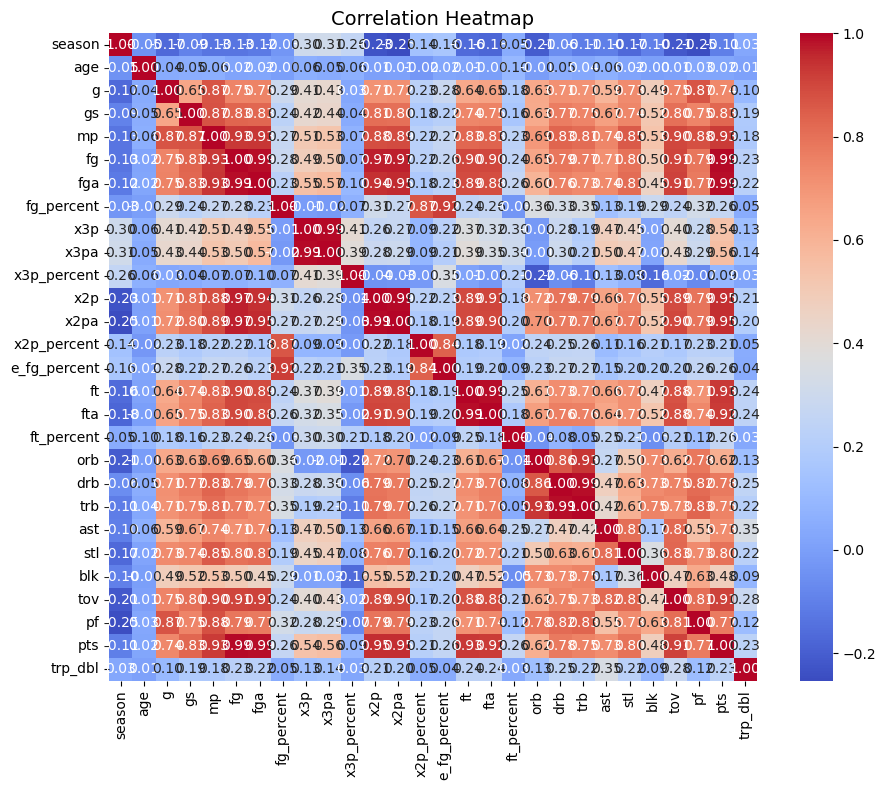

In [32]:
plot_corr_heatmap(player_total)

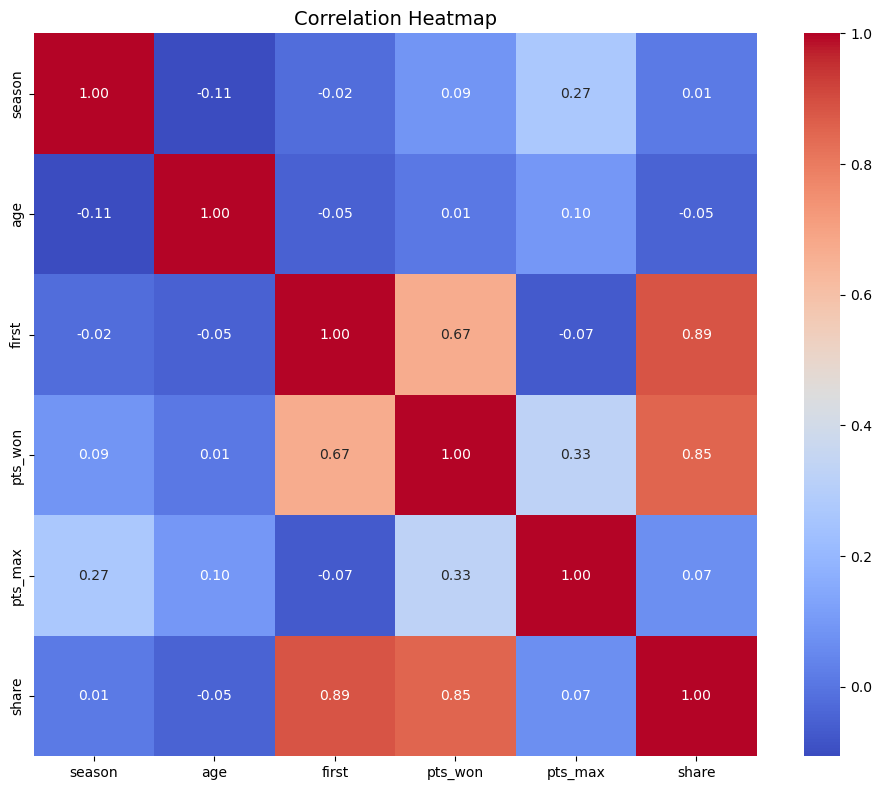

In [33]:
plot_corr_heatmap(player_Award_Shares)

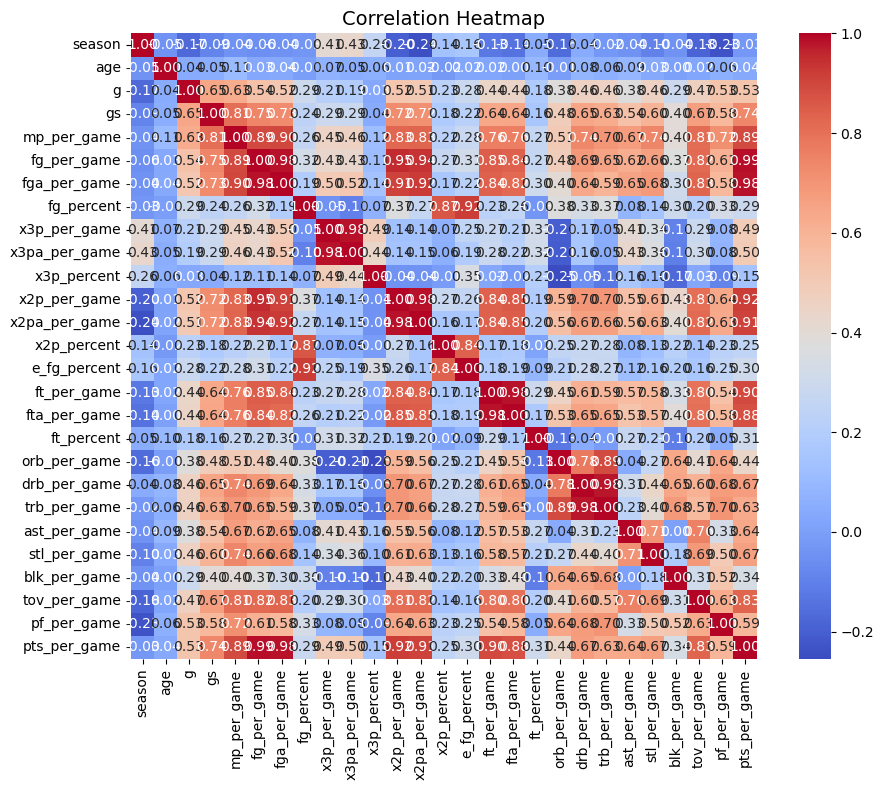

In [34]:
plot_corr_heatmap(player_per_game)

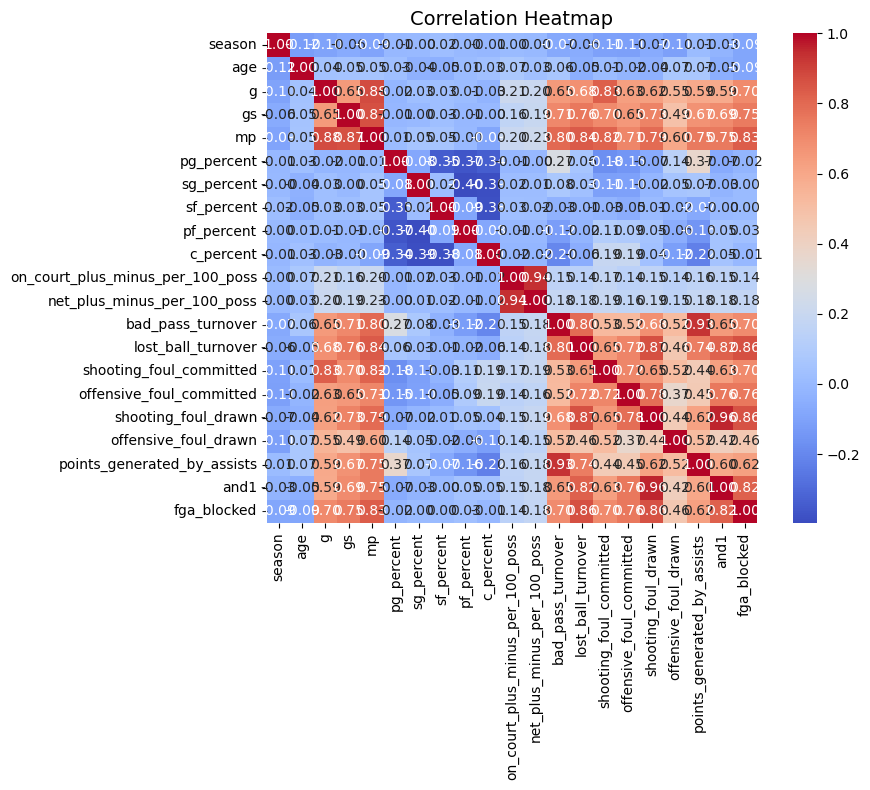

In [35]:
plot_corr_heatmap(player_play_by_play)

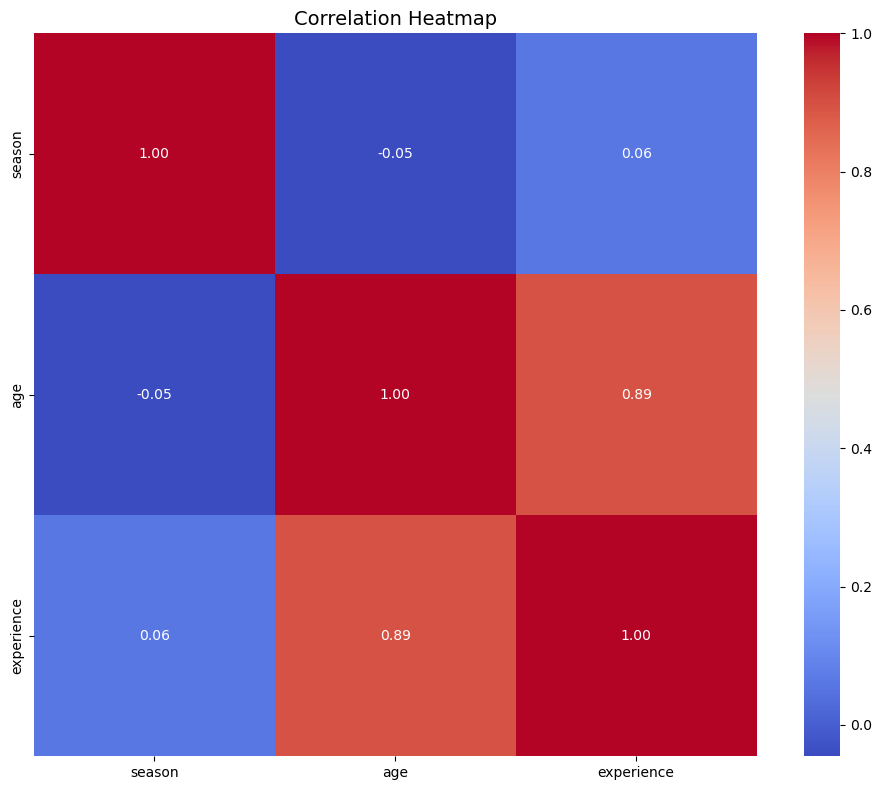

In [36]:
plot_corr_heatmap(player_season_info)

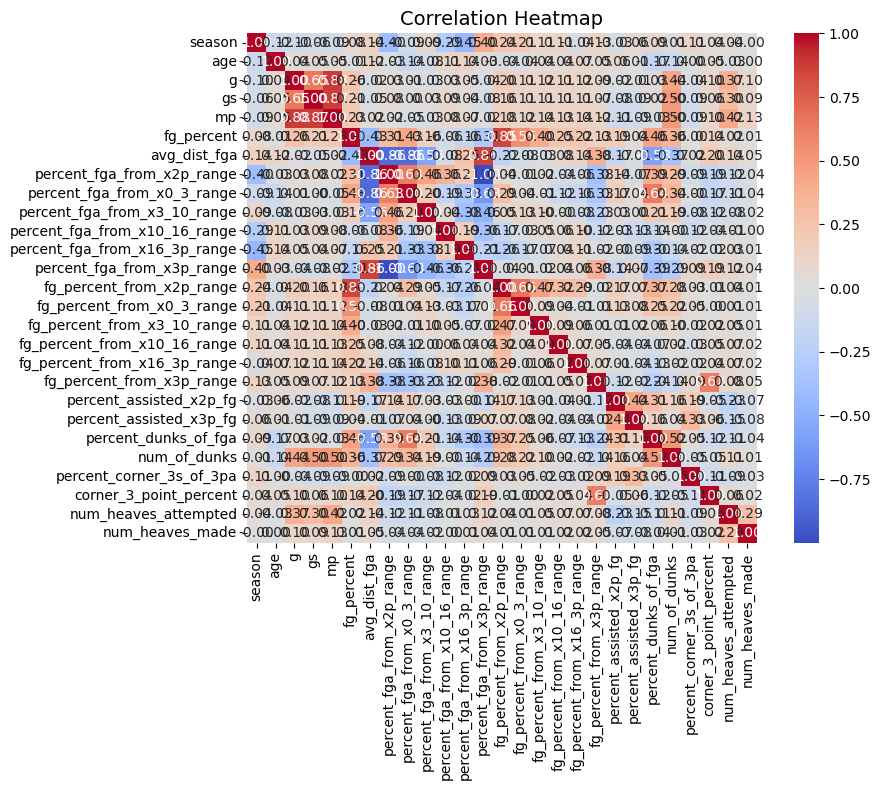

In [37]:
plot_corr_heatmap(player_shooting)

#### Outliers

In [38]:
def detect_outliers_iqr(df):
    """
    Summarize the proportion of outliers in each numeric column using IQR.
    
    Parameters:
        df (pd.DataFrame): Input dataset
    
    Returns:
        pd.DataFrame: Summary table with outlier counts and percentages
    """
    summary = []
    n = len(df)
    
    for col in df.select_dtypes(include="number").columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_count = outlier_mask.sum()
        
        summary.append({
            "Variable": col,
            "Outlier Count": outlier_count,
            "Outlier %": round((outlier_count / n) * 100, 2)
        })
    
    return pd.DataFrame(summary).sort_values("Outlier %", ascending=False)

In [39]:
detect_outliers_iqr(player_total)

,Variable,Outlier Count,Outlier %
8,x3p,2213,8.99
23,blk,2098,8.52
9,x3pa,1991,8.09
13,x2p_percent,1834,7.45
14,e_fg_percent,1727,7.02
21,ast,1633,6.63
7,fg_percent,1615,6.56
18,orb,1492,6.06
15,ft,1402,5.70
16,fta,1294,5.26


In [40]:
detect_outliers_iqr(player_Award_Shares)

,Variable,Outlier Count,Outlier %
4,pts_max,1199,41.39
2,first,521,17.98
3,pts_won,461,15.91
5,share,425,14.67
1,age,4,0.14
0,season,0,0.00


In [41]:
detect_outliers_iqr(player_per_game)

,Variable,Outlier Count,Outlier %
13,x2p_percent,1834,7.45
14,e_fg_percent,1727,7.02
23,blk_per_game,1723,7.00
7,fg_percent,1615,6.56
21,ast_per_game,1473,5.98
15,ft_per_game,1303,5.29
16,fta_per_game,1199,4.87
18,orb_per_game,999,4.06
19,drb_per_game,974,3.96
8,x3p_per_game,965,3.92


In [42]:
detect_outliers_iqr(player_play_by_play)

,Variable,Outlier Count,Outlier %
5,pg_percent,3654,20.85
9,c_percent,2909,16.60
6,sg_percent,1317,7.52
8,pf_percent,1300,7.42
18,points_generated_by_assists,1229,7.01
11,net_plus_minus_per_100_poss,1208,6.89
19,and1,1074,6.13
7,sf_percent,1067,6.09
16,shooting_foul_drawn,1046,5.97
10,on_court_plus_minus_per_100_poss,1012,5.78


In [43]:
detect_outliers_iqr(player_season_info)

,Variable,Outlier Count,Outlier %
1,age,367,1.49
2,experience,105,0.43
0,season,0,0.00


In [44]:
detect_outliers_iqr(player_shooting)

,Variable,Outlier Count,Outlier %
18,fg_percent_from_x3p_range,2458,14.03
17,fg_percent_from_x16_3p_range,2107,12.03
16,fg_percent_from_x10_16_range,2088,11.92
15,fg_percent_from_x3_10_range,1627,9.29
22,num_of_dunks,1610,9.19
25,num_heaves_attempted,1483,8.46
5,fg_percent,1345,7.68
14,fg_percent_from_x0_3_range,1307,7.46
21,percent_dunks_of_fga,1206,6.88
13,fg_percent_from_x2p_range,1166,6.65
